# Data Exploration of created books dataset 

In [5]:
import requests 
import pandas as pd 
import os 
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

In [28]:
#shape and columns of df 
print("shape: ", df.shape)
print("\ncolumns: ", df.columns.tolist())
print("\ndatatype: ", df.dtypes)

shape:  (886, 11)

columns:  ['title', 'authors', 'publisher', 'subject', 'categories', 'maturityRating', 'page_count', 'average_rating', 'ratings_count', 'published_date', 'description']

datatype:  title                        str
authors                      str
publisher                    str
subject                      str
categories                   str
maturityRating               str
page_count                 int64
average_rating           float64
ratings_count              int64
published_date    datetime64[us]
description                  str
dtype: object


In [29]:
#check for nulls 
print("missing values over columns: ")
print(df.isnull().sum())

#check for 0 values
print("\n0 values: ")
print((df[["page_count", "average_rating", "ratings_count"]] == 0).sum())

missing values over columns: 
title               0
authors             0
publisher           0
subject             0
categories          0
maturityRating      0
page_count          0
average_rating      0
ratings_count       0
published_date      0
description       106
dtype: int64

0 values: 
page_count          0
average_rating    764
ratings_count     764
dtype: int64


In [30]:
df[["page_count", "average_rating", "ratings_count"]].describe()


,page_count,average_rating,ratings_count
count,886.000000,886.000000,886.000000
mean,359.822799,0.558126,0.630926
std,194.793314,1.442203,5.452860
min,10.000000,0.000000,0.000000
25%,241.000000,0.000000,0.000000
50%,324.500000,0.000000,0.000000
75%,435.500000,0.000000,0.000000
max,2415.000000,5.000000,147.000000


page count distribution 

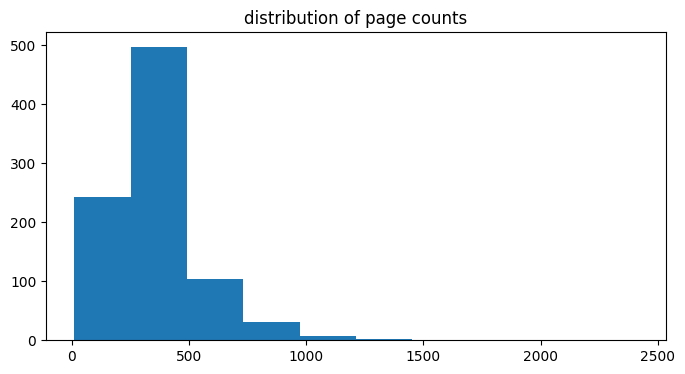

In [31]:
#remove 0 page counts
df_clean = df[df["page_count"] > 0]

plt.figure(figsize=(8, 4))
plt.hist(df_clean["page_count"], bins=10)
plt.title("distribution of page counts")
plt.show()

ratings

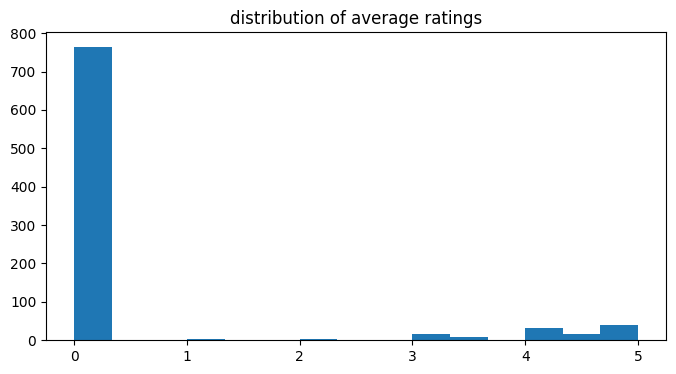

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean["average_rating"], bins=15)
plt.title("distribution of average ratings")
plt.show()

Genres

In [33]:
#determined by the genres given to API to pull 
genre_counts = df["subject"].value_counts()
genre_counts

subject
self help             94
fiction               89
mystery               87
science               87
science fiction       82
biography             82
thriller              79
nonfiction            77
fantasy               76
romance               74
historical fiction    59
Name: count, dtype: int64

categories

In [34]:
#one layer down from genre 
category_counts = df["categories"].value_counts()
category_counts = category_counts[category_counts > 1]

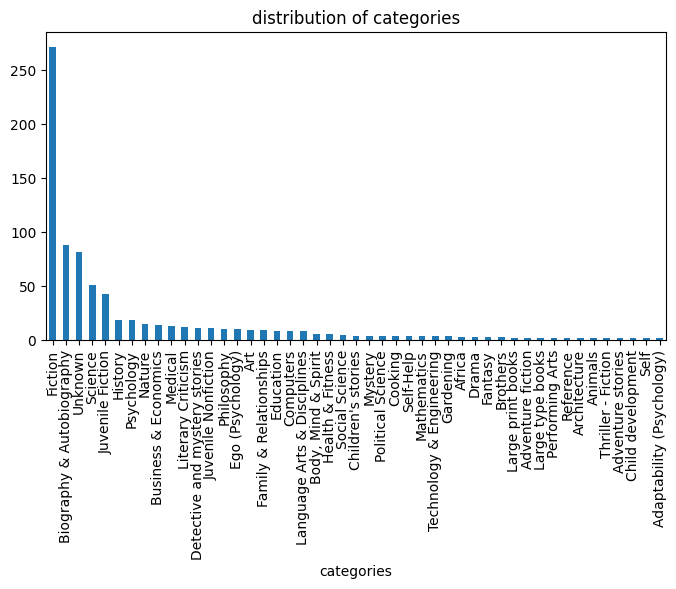

In [35]:
plt.figure(figsize=(8, 4))
category_counts.plot(kind="bar")
plt.title("distribution of categories")
plt.show()

Published Date 

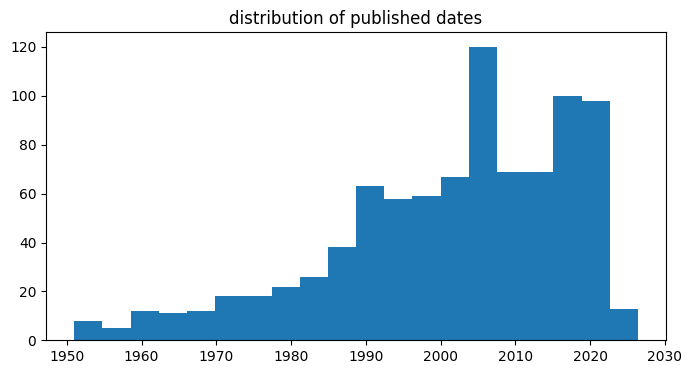

In [36]:
plt.figure(figsize = (8, 4))
plt.hist(df["published_date"], bins=20)
plt.title("distribution of published dates")
plt.show()

In [37]:
df["published_date"].describe()

count                           886
mean     2001-05-14 08:14:05.146726
min             1951-01-01 00:00:00
25%             1992-01-01 00:00:00
50%             2004-02-18 00:00:00
75%             2014-08-19 18:00:00
max             2026-05-28 00:00:00
Name: published_date, dtype: object